# Stateful vs Stateless Analysis

This notebook provides a focused analysis comparing the performance of stateful vs stateless configurations in the MMLLM benchmarking framework.

## Overview

We will specifically analyze:
1. **Performance Comparison**: Direct comparison between stateful and stateless configurations
2. **Memory Impact**: How state management affects different types of tasks
3. **Efficiency Analysis**: Speed vs accuracy trade-offs
4. **Dataset-Specific Effects**: Which datasets benefit most from state management
5. **Context Retention**: Analysis of how state affects multi-step reasoning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Load data from stateful vs stateless experiments
RESULTS_PATH = Path("../results/stateless-vs-statefull")
print(f"Stateful vs Stateless analysis path: {RESULTS_PATH.absolute()}")
print(f"Path exists: {RESULTS_PATH.exists()}")

# Load stateful and stateless data
stateful_csv = RESULTS_PATH / "statefull" / "benchmark_results_20250720_125011.csv"
stateless_csv = RESULTS_PATH / "stateless" / "benchmark_results_20250720_121356.csv"

stateful_json = RESULTS_PATH / "statefull" / "benchmark_report_20250720_125011.json"
stateless_json = RESULTS_PATH / "stateless" / "benchmark_report_20250720_121356.json"

# Check file existence
print(f"Stateful CSV exists: {stateful_csv.exists()}")
print(f"Stateless CSV exists: {stateless_csv.exists()}")
print(f"Stateful JSON exists: {stateful_json.exists()}")
print(f"Stateless JSON exists: {stateless_json.exists()}")

# Load the data
stateful_data = pd.read_csv(stateful_csv) if stateful_csv.exists() else pd.DataFrame()
stateless_data = pd.read_csv(stateless_csv) if stateless_csv.exists() else pd.DataFrame()

stateful_data['config'] = 'stateful'
stateless_data['config'] = 'stateless'

combined_state_data = pd.concat([stateful_data, stateless_data], ignore_index=True)

print(f"Stateful data shape: {stateful_data.shape}")
print(f"Stateless data shape: {stateless_data.shape}")
print(f"Combined data shape: {combined_state_data.shape}")

Stateful vs Stateless analysis path: /home/kiko/mmllm/vis/../results/stateless-vs-statefull
Path exists: True
Stateful CSV exists: True
Stateless CSV exists: True
Stateful JSON exists: True
Stateless JSON exists: True
Stateful data shape: (233, 39)
Stateless data shape: (236, 39)
Combined data shape: (469, 39)


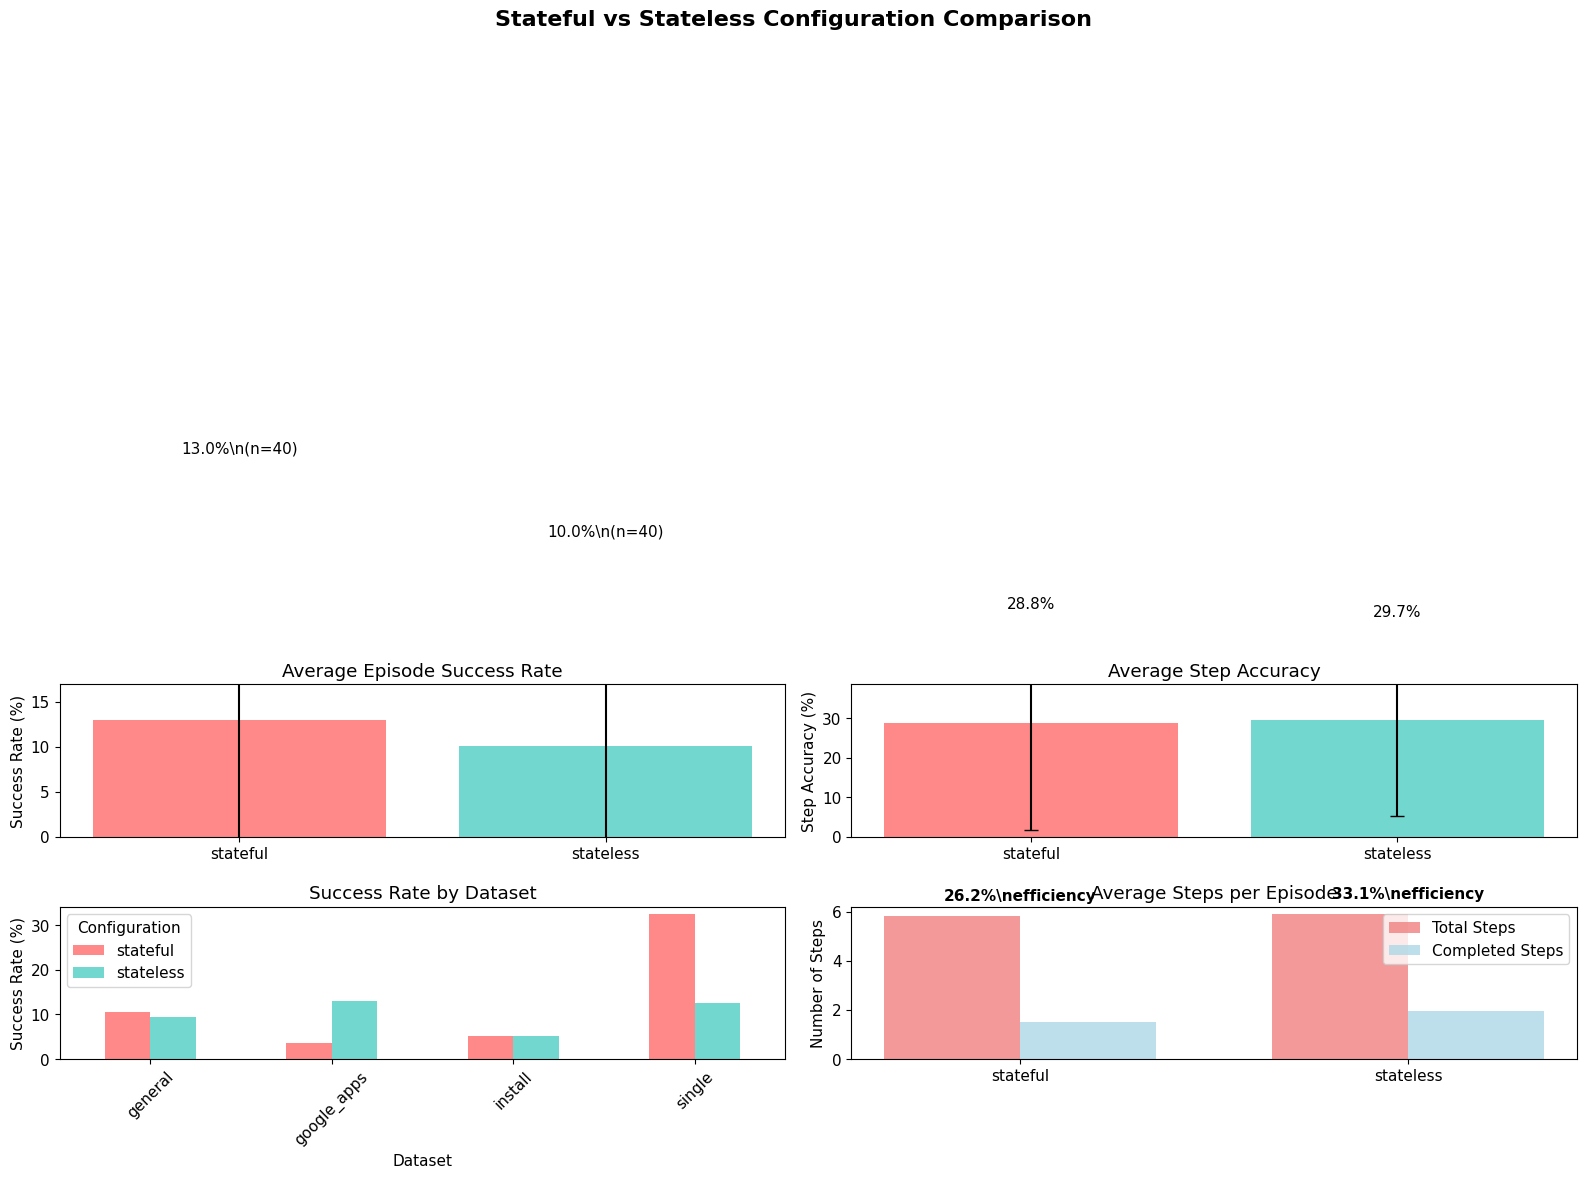

\n============================================================
STATEFUL VS STATELESS DETAILED COMPARISON
\nSTATEFUL Configuration:
  Episodes analyzed: 40
  Average success rate: 12.99% (±27.27)
  Average step accuracy: 28.85% (±27.17)
  Average total steps: 5.8 (±3.5)
  Average completed steps: 1.5 (±1.4)
  Dataset performance:
    google_apps: 3.7% (n=10)
    general: 10.6% (n=10)
    install: 5.2% (n=10)
    single: 32.5% (n=10)
\nSTATELESS Configuration:
  Episodes analyzed: 40
  Average success rate: 10.03% (±21.00)
  Average step accuracy: 29.66% (±24.35)
  Average total steps: 5.9 (±3.5)
  Average completed steps: 1.9 (±1.8)
  Dataset performance:
    google_apps: 12.9% (n=10)
    general: 9.4% (n=10)
    install: 5.2% (n=10)
    single: 12.5% (n=10)


In [2]:
# Create comprehensive stateful vs stateless comparison
if not combined_state_data.empty:
    
    # Calculate episode-level metrics
    episode_metrics = combined_state_data.groupby(['config', 'episode_id']).agg({
        'episode_success_rate': 'first',
        'episode_step_accuracy': 'first',
        'episode_total_steps': 'first',
        'episode_steps_completed': 'first',
        'dataset_name': 'first'
    }).reset_index()
    
    # Create comparison visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Stateful vs Stateless Configuration Comparison', fontsize=16, fontweight='bold')
    
    # 1. Success Rate Comparison
    ax1 = axes[0, 0]
    success_comparison = episode_metrics.groupby('config')['episode_success_rate'].agg(['mean', 'std', 'count'])
    
    bars = ax1.bar(success_comparison.index, success_comparison['mean'], 
                   yerr=success_comparison['std'], capsize=5,
                   color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
    ax1.set_title('Average Episode Success Rate')
    ax1.set_ylabel('Success Rate (%)')
    ax1.set_ylim(0, max(success_comparison['mean']) * 1.3)
    
    # Add value labels and sample sizes
    for i, (bar, count) in enumerate(zip(bars, success_comparison['count'])):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + success_comparison['std'].iloc[i] + 2,
                f'{height:.1f}%\\n(n={count})', ha='center', va='bottom')
    
    # 2. Step Accuracy Comparison  
    ax2 = axes[0, 1]
    accuracy_comparison = episode_metrics.groupby('config')['episode_step_accuracy'].agg(['mean', 'std'])
    
    bars = ax2.bar(accuracy_comparison.index, accuracy_comparison['mean'],
                   yerr=accuracy_comparison['std'], capsize=5,
                   color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
    ax2.set_title('Average Step Accuracy')
    ax2.set_ylabel('Step Accuracy (%)')
    ax2.set_ylim(0, max(accuracy_comparison['mean']) * 1.3)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + accuracy_comparison['std'].iloc[i] + 1,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # 3. Performance by Dataset
    ax3 = axes[1, 0]
    dataset_performance = episode_metrics.groupby(['dataset_name', 'config'])['episode_success_rate'].mean().unstack(fill_value=0)
    
    dataset_performance.plot(kind='bar', ax=ax3, color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
    ax3.set_title('Success Rate by Dataset')
    ax3.set_ylabel('Success Rate (%)')
    ax3.set_xlabel('Dataset')
    ax3.legend(title='Configuration')
    ax3.tick_params(axis='x', rotation=45)
    
    # 4. Efficiency Analysis (Steps)
    ax4 = axes[1, 1]
    
    # Calculate efficiency metrics
    efficiency_data = []
    for config in ['stateful', 'stateless']:
        config_data = episode_metrics[episode_metrics['config'] == config]
        avg_total_steps = config_data['episode_total_steps'].mean()
        avg_completed_steps = config_data['episode_steps_completed'].mean()
        completion_rate = (avg_completed_steps / avg_total_steps) * 100 if avg_total_steps > 0 else 0
        
        efficiency_data.append({
            'config': config,
            'avg_total_steps': avg_total_steps,
            'avg_completed_steps': avg_completed_steps,
            'completion_rate': completion_rate
        })
    
    efficiency_df = pd.DataFrame(efficiency_data)
    
    x_pos = np.arange(len(efficiency_df))
    width = 0.35
    
    bars1 = ax4.bar(x_pos - width/2, efficiency_df['avg_total_steps'], width,
                   label='Total Steps', alpha=0.8, color='lightcoral')
    bars2 = ax4.bar(x_pos + width/2, efficiency_df['avg_completed_steps'], width,
                   label='Completed Steps', alpha=0.8, color='lightblue')
    
    ax4.set_title('Average Steps per Episode')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(efficiency_df['config'])
    ax4.set_ylabel('Number of Steps')
    ax4.legend()
    
    # Add efficiency percentages
    for i, (total, completed) in enumerate(zip(efficiency_df['avg_total_steps'], efficiency_df['avg_completed_steps'])):
        efficiency = (completed / total) * 100 if total > 0 else 0
        ax4.text(i, max(total, completed) + 0.5, f'{efficiency:.1f}%\\nefficiency', 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\\n" + "="*60)
    print("STATEFUL VS STATELESS DETAILED COMPARISON")
    print("="*60)
    
    for config in ['stateful', 'stateless']:
        config_data = episode_metrics[episode_metrics['config'] == config]
        print(f"\\n{config.upper()} Configuration:")
        print(f"  Episodes analyzed: {len(config_data)}")
        print(f"  Average success rate: {config_data['episode_success_rate'].mean():.2f}% (±{config_data['episode_success_rate'].std():.2f})")
        print(f"  Average step accuracy: {config_data['episode_step_accuracy'].mean():.2f}% (±{config_data['episode_step_accuracy'].std():.2f})")
        print(f"  Average total steps: {config_data['episode_total_steps'].mean():.1f} (±{config_data['episode_total_steps'].std():.1f})")
        print(f"  Average completed steps: {config_data['episode_steps_completed'].mean():.1f} (±{config_data['episode_steps_completed'].std():.1f})")
        
        # Dataset breakdown
        print(f"  Dataset performance:")
        for dataset in config_data['dataset_name'].unique():
            dataset_perf = config_data[config_data['dataset_name'] == dataset]['episode_success_rate'].mean()
            dataset_count = len(config_data[config_data['dataset_name'] == dataset])
            print(f"    {dataset}: {dataset_perf:.1f}% (n={dataset_count})")

else:
    print("No stateful vs stateless data available!")

## State Management Impact Analysis

Let's analyze how state management affects performance across different action types and error patterns.

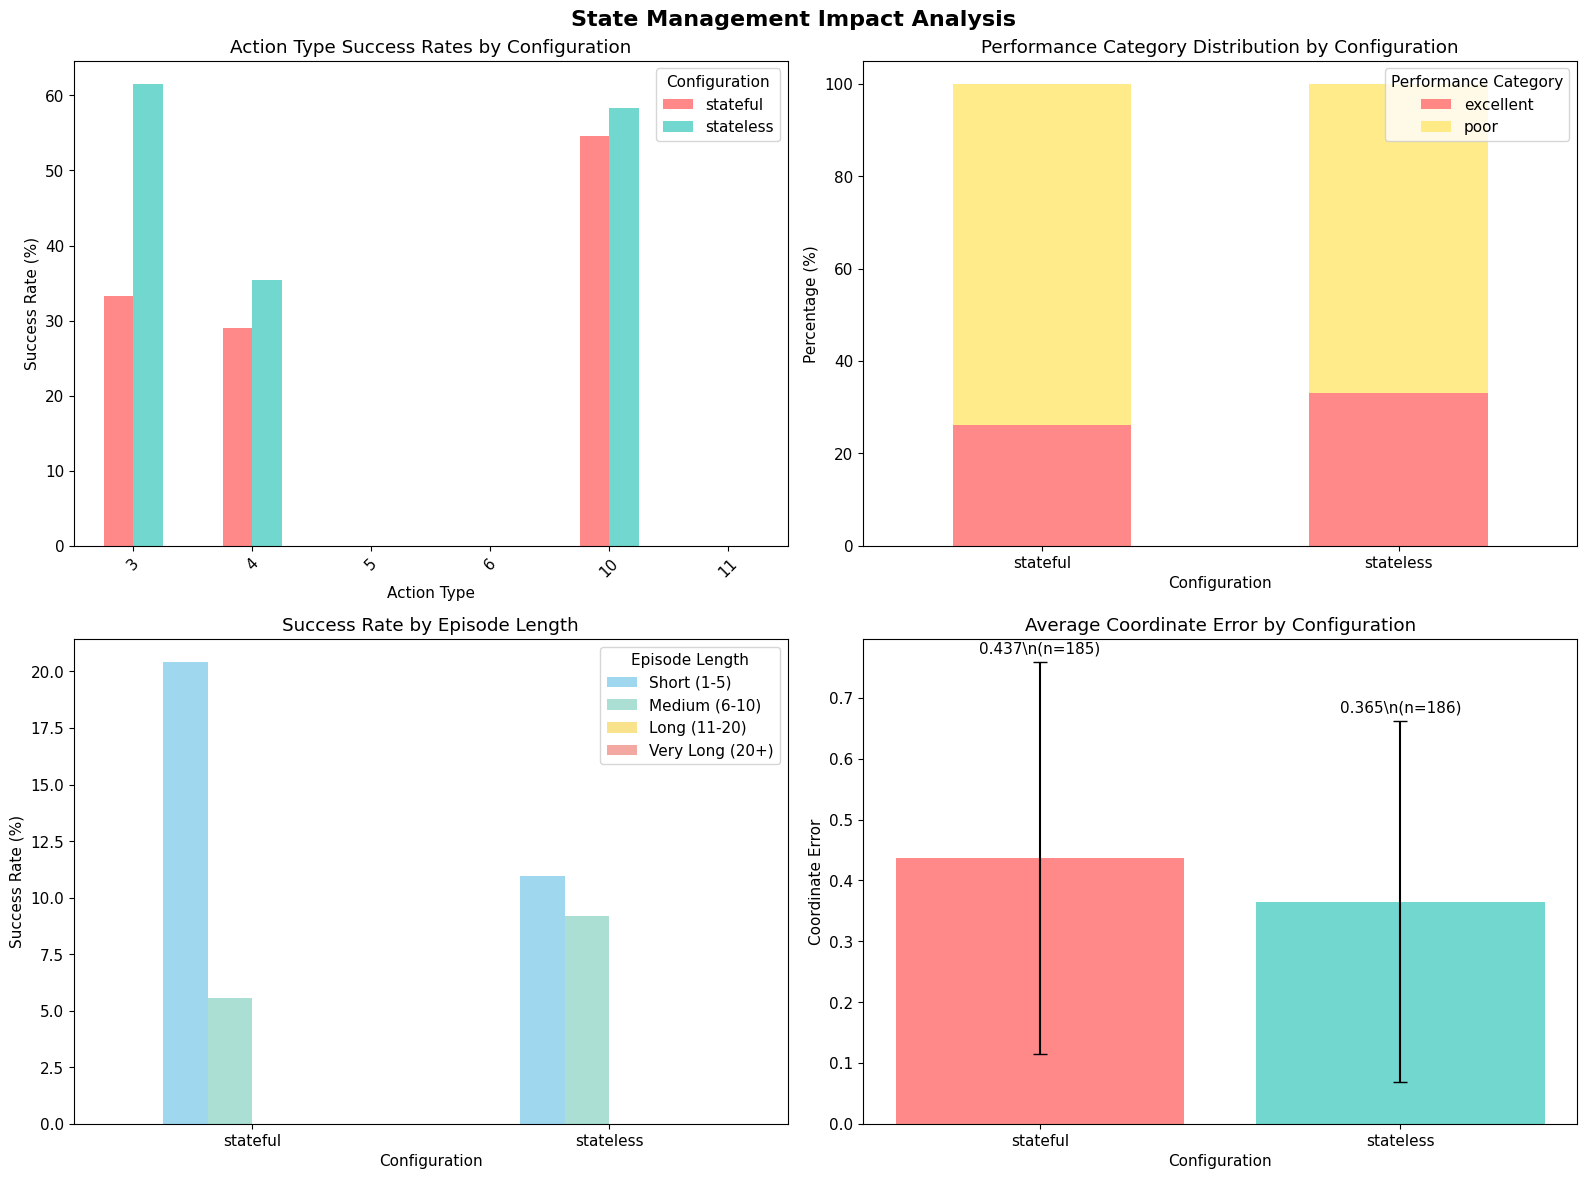

\n======================================================================
STATE MANAGEMENT INSIGHTS
\nAction Type Performance Differences:
  3: Stateful 33.3% vs Stateless 61.5% (diff: -28.2%)
  4: Stateful 29.1% vs Stateless 35.4% (diff: -6.3%)
  5: Stateful 0.0% vs Stateless 0.0% (diff: +0.0%)
  6: Stateful 0.0% vs Stateless 0.0% (diff: +0.0%)
  10: Stateful 54.5% vs Stateless 58.3% (diff: -3.8%)
  11: Stateful 0.0% vs Stateless nan% (diff: +nan%)
\nEpisode Length Impact:
  Short (1-5): Stateful 20.4% vs Stateless 11.0% (diff: +9.5%)
  Medium (6-10): Stateful 5.6% vs Stateless 9.2% (diff: -3.6%)
  Long (11-20): Stateful nan% vs Stateless nan% (diff: +nan%)
  Very Long (20+): Stateful nan% vs Stateless nan% (diff: +nan%)


In [3]:
# Analyze state management impact on different action types
if not combined_state_data.empty:
    
    # Create state-specific analysis
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('State Management Impact Analysis', fontsize=16, fontweight='bold')
    
    # 1. Action Type Success Rates by Configuration
    ax1 = axes[0, 0]
    action_success = combined_state_data.groupby(['config', 'model_action_type']).agg({
        'step_action_match': ['count', 'sum']
    })
    action_success.columns = ['total', 'successful']
    action_success['success_rate'] = (action_success['successful'] / action_success['total']) * 100
    action_success = action_success.reset_index()
    
    action_pivot = action_success.pivot(index='model_action_type', columns='config', values='success_rate')
    action_pivot.plot(kind='bar', ax=ax1, color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
    ax1.set_title('Action Type Success Rates by Configuration')
    ax1.set_ylabel('Success Rate (%)')
    ax1.set_xlabel('Action Type')
    ax1.legend(title='Configuration')
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. Performance Category Distribution
    ax2 = axes[0, 1]
    perf_by_config = combined_state_data.groupby(['config', 'performance_category']).size().unstack(fill_value=0)
    perf_by_config_pct = perf_by_config.div(perf_by_config.sum(axis=1), axis=0) * 100
    
    perf_by_config_pct.plot(kind='bar', ax=ax2, stacked=True, 
                           color=['#FF6B6B', '#FFE66D', '#4ECDC4'], alpha=0.8)
    ax2.set_title('Performance Category Distribution by Configuration')
    ax2.set_ylabel('Percentage (%)')
    ax2.set_xlabel('Configuration')
    ax2.legend(title='Performance Category')
    ax2.tick_params(axis='x', rotation=0)
    
    # 3. Multi-step reasoning analysis (episode length impact)
    ax3 = axes[1, 0]
    
    # Bin episodes by length
    combined_state_data['step_length_bin'] = pd.cut(combined_state_data['episode_total_steps'], 
                                                   bins=[0, 5, 10, 20, float('inf')], 
                                                   labels=['Short (1-5)', 'Medium (6-10)', 'Long (11-20)', 'Very Long (20+)'])
    
    episode_length_perf = combined_state_data.groupby(['config', 'step_length_bin', 'episode_id']).agg({
        'episode_success_rate': 'first'
    }).reset_index()
    
    length_success = episode_length_perf.groupby(['config', 'step_length_bin'])['episode_success_rate'].mean().unstack(fill_value=0)
    length_success.plot(kind='bar', ax=ax3, color=['#87CEEB', '#98D8C8', '#F7DC6F', '#F1948A'], alpha=0.8)
    ax3.set_title('Success Rate by Episode Length')
    ax3.set_ylabel('Success Rate (%)')
    ax3.set_xlabel('Configuration')
    ax3.legend(title='Episode Length')
    ax3.tick_params(axis='x', rotation=0)
    
    # 4. Coordinate Error Analysis
    ax4 = axes[1, 1]
    coord_data = combined_state_data[combined_state_data['coordinate_error'].notna()]
    if not coord_data.empty:
        coord_by_config = coord_data.groupby('config')['coordinate_error'].agg(['mean', 'std', 'count'])
        
        bars = ax4.bar(coord_by_config.index, coord_by_config['mean'],
                      yerr=coord_by_config['std'], capsize=5,
                      color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
        ax4.set_title('Average Coordinate Error by Configuration')
        ax4.set_ylabel('Coordinate Error')
        ax4.set_xlabel('Configuration')
        
        # Add value labels
        for i, (bar, count) in enumerate(zip(bars, coord_by_config['count'])):
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height + coord_by_config['std'].iloc[i] + 0.01,
                    f'{height:.3f}\\n(n={count})', ha='center', va='bottom')
    else:
        ax4.text(0.5, 0.5, 'No coordinate data available', 
                ha='center', va='center', transform=ax4.transAxes)
    
    plt.tight_layout()
    plt.show()
    
    # Print state management insights
    print("\\n" + "="*70)
    print("STATE MANAGEMENT INSIGHTS")
    print("="*70)
    
    # Compare action type performance
    print("\\nAction Type Performance Differences:")
    for action_type in action_pivot.index:
        if 'stateful' in action_pivot.columns and 'stateless' in action_pivot.columns:
            stateful_perf = action_pivot.loc[action_type, 'stateful']
            stateless_perf = action_pivot.loc[action_type, 'stateless']
            diff = stateful_perf - stateless_perf
            print(f"  {action_type}: Stateful {stateful_perf:.1f}% vs Stateless {stateless_perf:.1f}% (diff: {diff:+.1f}%)")
    
    # Episode length impact
    print("\\nEpisode Length Impact:")
    for length_bin in length_success.columns:
        if 'stateful' in length_success.index and 'stateless' in length_success.index:
            stateful_perf = length_success.loc['stateful', length_bin]
            stateless_perf = length_success.loc['stateless', length_bin]
            diff = stateful_perf - stateless_perf
            print(f"  {length_bin}: Stateful {stateful_perf:.1f}% vs Stateless {stateless_perf:.1f}% (diff: {diff:+.1f}%)")

else:
    print("No data available for state management analysis!")

## JSON Report Analysis

Let's load and analyze the structured JSON reports for additional insights.

Loaded JSON reports successfully!


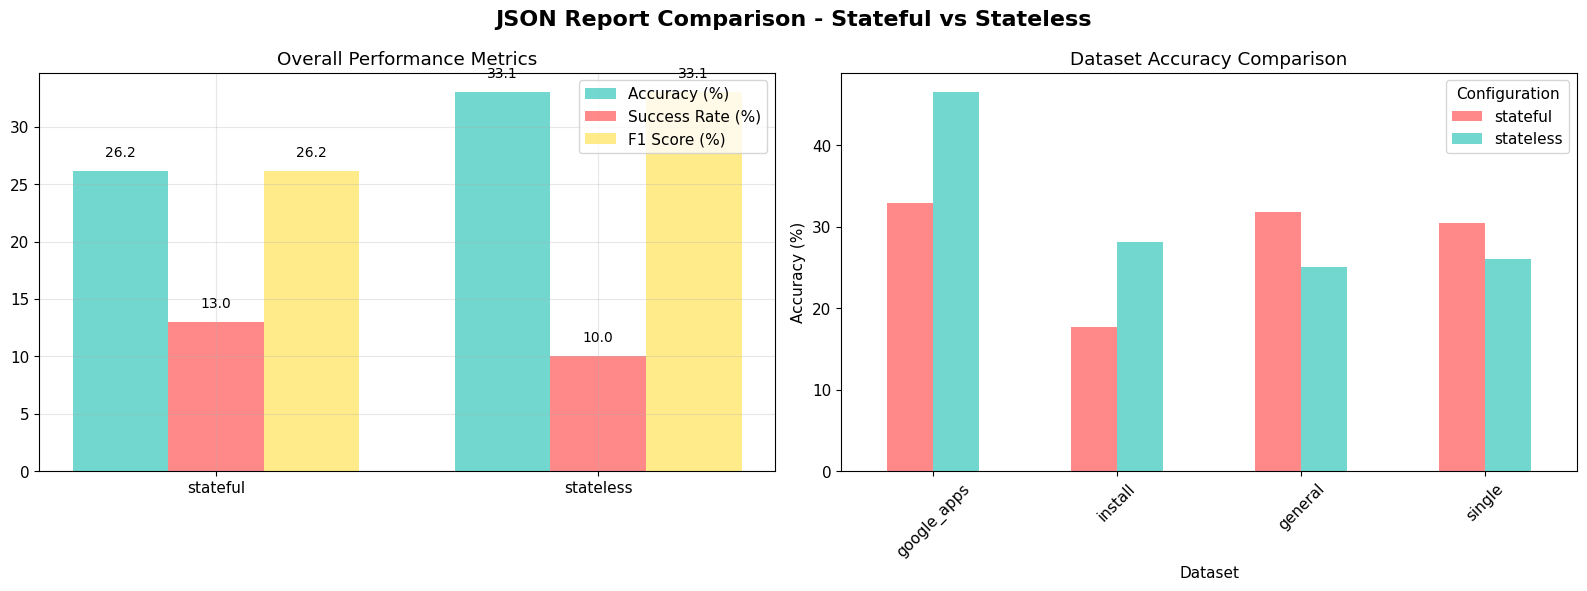

\n======================================================================
JSON REPORT DETAILED COMPARISON
\nSTATEFUL Configuration:
  Overall Accuracy: 26.18%
  Success Rate: 12.99%
  F1 Score: 0.262
  Precision: 0.262
  Recall: 0.262
  Total Episodes: 40
  Total Steps: 233
  Dataset Performance:
    general: 31.8% accuracy
    google_apps: 32.9% accuracy
    install: 17.7% accuracy
    single: 30.4% accuracy
\nSTATELESS Configuration:
  Overall Accuracy: 33.05%
  Success Rate: 10.03%
  F1 Score: 0.331
  Precision: 0.331
  Recall: 0.331
  Total Episodes: 40
  Total Steps: 236
  Dataset Performance:
    general: 25.0% accuracy
    google_apps: 46.6% accuracy
    install: 28.1% accuracy
    single: 26.1% accuracy


In [4]:
# Load and analyze JSON reports
def load_json_report(file_path):
    """Load JSON report file safely"""
    try:
        with open(file_path, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# Load both reports
stateful_report = load_json_report(stateful_json) if stateful_json.exists() else None
stateless_report = load_json_report(stateless_json) if stateless_json.exists() else None

if stateful_report and stateless_report:
    print("Loaded JSON reports successfully!")
    
    # Create JSON report comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('JSON Report Comparison - Stateful vs Stateless', fontsize=16, fontweight='bold')
    
    # 1. Overall metrics comparison
    ax1 = axes[0]
    
    if 'overall_metrics' in stateful_report and 'overall_metrics' in stateless_report:
        metrics_data = {
            'stateful': stateful_report['overall_metrics'],
            'stateless': stateless_report['overall_metrics']
        }
        
        configs = list(metrics_data.keys())
        accuracy = [metrics_data[config]['accuracy'] * 100 for config in configs]
        success_rate = [metrics_data[config]['success_rate'] for config in configs]
        f1_score = [metrics_data[config]['f1_score'] * 100 for config in configs]
        
        x_pos = np.arange(len(configs))
        width = 0.25
        
        bars1 = ax1.bar(x_pos - width, accuracy, width, label='Accuracy (%)', alpha=0.8, color='#4ECDC4')
        bars2 = ax1.bar(x_pos, success_rate, width, label='Success Rate (%)', alpha=0.8, color='#FF6B6B')
        bars3 = ax1.bar(x_pos + width, f1_score, width, label='F1 Score (%)', alpha=0.8, color='#FFE66D')
        
        ax1.set_title('Overall Performance Metrics')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(configs)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Add value labels
        for bars in [bars1, bars2, bars3]:
            for bar in bars:
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                        f'{height:.1f}', ha='center', va='bottom', fontsize=10)
    
    # 2. Dataset-specific performance
    ax2 = axes[1]
    
    if 'dataset_metrics' in stateful_report and 'dataset_metrics' in stateless_report:
        dataset_comparison = {}
        
        # Combine dataset metrics
        all_datasets = set(stateful_report['dataset_metrics'].keys()) | set(stateless_report['dataset_metrics'].keys())
        
        for dataset in all_datasets:
            dataset_comparison[dataset] = {
                'stateful': stateful_report['dataset_metrics'].get(dataset, {}).get('accuracy', 0) * 100,
                'stateless': stateless_report['dataset_metrics'].get(dataset, {}).get('accuracy', 0) * 100
            }
        
        dataset_df = pd.DataFrame(dataset_comparison).T
        dataset_df.plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
        ax2.set_title('Dataset Accuracy Comparison')
        ax2.set_ylabel('Accuracy (%)')
        ax2.set_xlabel('Dataset')
        ax2.legend(title='Configuration')
        ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed report comparison
    print("\\n" + "="*70)
    print("JSON REPORT DETAILED COMPARISON")
    print("="*70)
    
    for config_name, report in [('STATEFUL', stateful_report), ('STATELESS', stateless_report)]:
        print(f"\\n{config_name} Configuration:")
        
        if 'overall_metrics' in report:
            metrics = report['overall_metrics']
            print(f"  Overall Accuracy: {metrics.get('accuracy', 0)*100:.2f}%")
            print(f"  Success Rate: {metrics.get('success_rate', 0):.2f}%")
            print(f"  F1 Score: {metrics.get('f1_score', 0):.3f}")
            print(f"  Precision: {metrics.get('precision', 0):.3f}")
            print(f"  Recall: {metrics.get('recall', 0):.3f}")
            print(f"  Total Episodes: {metrics.get('total_episodes', 0)}")
            print(f"  Total Steps: {metrics.get('total_steps', 0)}")
        
        if 'dataset_metrics' in report:
            print(f"  Dataset Performance:")
            for dataset, dataset_metrics in report['dataset_metrics'].items():
                print(f"    {dataset}: {dataset_metrics.get('accuracy', 0)*100:.1f}% accuracy")

else:
    print("Could not load JSON reports for comparison.")